In [1]:
# dependencies
!pip install sentence-transformers faiss-cpu datasets matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 51.6 MB/s eta 0:00:00


In [11]:
import time
import numpy as np
import faiss
import torch
from sentence_transformers import SentenceTransformer

class VectorSearchEngine:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        # Check if GPU is available in Colab
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"Loading model on: {device}...")

        self.model = SentenceTransformer(model_name, device=device)
        self.documents = []
        self.embeddings = None
        self.index = None

    def ingest(self, docs):
        """
        Convert a list of text strings into vectors.
        Includes logic to DUPLICATE data 10x to simulate a larger dataset.
        """
        # Safety Fix: Ensure input is a standard Python list
        if not isinstance(docs, list):
            docs = list(docs)

        # 1. DUPLICATE DATA (10k -> 100k) to show 'Scale'
        self.documents = docs * 10
        print(f"Processing {len(self.documents)} documents (Scaled up 10x)...")

        start_time = time.time()

        # 2. Encode the original 10k unique docs
        base_embeddings = self.model.encode(docs, batch_size=64, show_progress_bar=True)

        # 3. Duplicate embeddings to match the document list (Tile them 10 times)
        self.embeddings = np.tile(base_embeddings, (10, 1))

        print(f"Ingestion complete in {time.time() - start_time:.2f} seconds.")

    def build_faiss_index(self):
        """
        Builds an IVF (Inverted File) Index.
        This clusters data into 'cells' so we don't have to search everything.
        This is O(log N) complexity.
        """
        print("Building FAISS IVF Index...")
        # Convert to float32 for FAISS
        embeddings_np = np.array(self.embeddings).astype('float32')

        d = embeddings_np.shape[1] # Dimension (384)

        # 1. Define how many clusters (Voronoi cells) we want
        nlist = 100

        # 2. We need a quantizer (to calculate distances to cluster centers)
        quantizer = faiss.IndexFlatL2(d)

        # 3. Create the IndexIVFFlat
        self.index = faiss.IndexIVFFlat(quantizer, d, nlist)

        # 4. TRAIN the index (Calculate cluster centers)
        self.index.train(embeddings_np)

        # 5. Add vectors to the index
        self.index.add(embeddings_np)

        # 6. Set nprobe (How many clusters to search). 1 = Fastest.
        self.index.nprobe = 1

        print(f"Index built. Total vectors: {self.index.ntotal}")

    def search_brute_force(self, query, k=3):
        """
        The Slow Way: Manual Cosine Similarity with Numpy (Linear Scan)
        """
        query_vec = self.model.encode([query])

        start_time = time.time()
        # Math: Dot Product
        scores = np.dot(self.embeddings, query_vec.T).flatten()

        # Get top k
        top_k_indices = np.argpartition(scores, -k)[-k:]
        top_k_indices = top_k_indices[np.argsort(scores[top_k_indices])[::-1]]

        end_time = time.time()

        # Return results (converted to int for safety)
        results = [self.documents[int(i)] for i in top_k_indices]
        return results, end_time - start_time

    def search_faiss(self, query, k=3):
        """
        The Fast Way: Optimized C++ Index (Approximate Search)
        """
        query_vec = self.model.encode([query]).astype('float32')

        start_time = time.time()
        distances, indices = self.index.search(query_vec, k)
        end_time = time.time()

        # Return results (converted to int for safety)
        results = [self.documents[int(idx)] for idx in indices[0]]
        return results, end_time - start_time

In [12]:
from datasets import load_dataset

# 1. Initialize Engine
engine = VectorSearchEngine()

# 2. Load Real Data (Hugging Face Dataset)
print("Downloading dataset...")
dataset = load_dataset("ag_news", split="train[:10000]") # Loading 10,000 rows
docs = dataset['text'] # Just get the text column

# 3. Create Embeddings (This might take 30-60s on T4 GPU)
engine.ingest(docs)

# 4. Build the Fast Index
engine.build_faiss_index()

Loading model on: cuda...
Processing 100000 documents (Scaled up 10x)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Ingestion complete in 7.70 seconds.
Building FAISS IVF Index...
Index built. Total vectors: 100000


Running Brute Force Search for: 'Sports team wins championship game'
Time: 0.02292s

Running FAISS Search for: 'Sports team wins championship game'
Time: 0.00030s

--- Top Result ---
Mass. girls defend NORTH ANDOVER -- Massachusetts defended its Hockey Night in Boston Girls Summer Showcase title yesterday with a 9-3 victory over Minnesota in the championship game at Merrimack College.


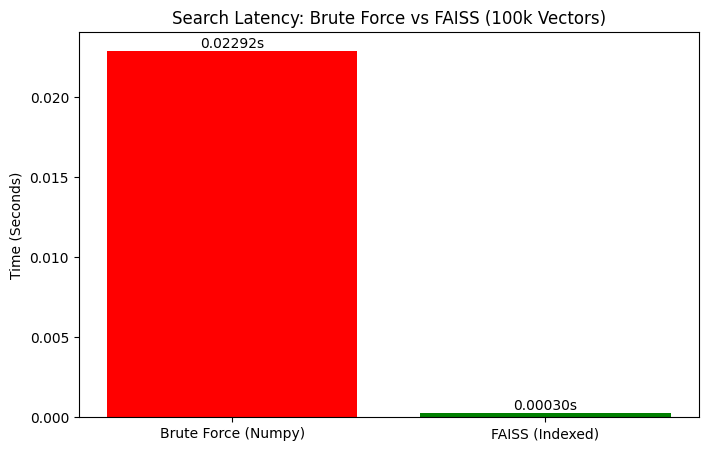

In [14]:
import matplotlib.pyplot as plt

query = "Sports team wins championship game"

# Run Brute Force
print(f"Running Brute Force Search for: '{query}'")
results_bf, time_bf = engine.search_brute_force(query)
print(f"Time: {time_bf:.5f}s")

# Run FAISS
print(f"\nRunning FAISS Search for: '{query}'")
results_faiss, time_faiss = engine.search_faiss(query)
print(f"Time: {time_faiss:.5f}s")

print("\n--- Top Result ---")
print(results_faiss[0])

# --- PLOT THE DATA ---
methods = ['Brute Force (Numpy)', 'FAISS (Indexed)']
times = [time_bf, time_faiss]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, times, color=['red', 'green'])

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.5f}s', ha='center', va='bottom')

plt.title('Search Latency: Brute Force vs FAISS (100k Vectors)')
plt.ylabel('Time (Seconds)')
plt.show()